In [1]:
using DifferentialEquations, LinearAlgebra, Random
using ForwardDiff, Zygote
using Lux, ComponentArrays, SciMLSensitivity, Optimisers
using CUDA, cuDNN
using ProgressBars, Plots

In [2]:
# In-place mutating function for speed during simulation
function nri_spring_physics!(dx, x, p, t)
    k, L = p # stiffness, rest length
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist = norm(r_ij)
                if dist > 1e-4 # Avoid singularity if they perfectly overlap
                    # Force is proportional to (1 - L/dist)
                    dx[:, i] .+= -k * (1.0 - L/dist) .* r_ij
                end
            end
        end
    end
end

function swirling_spring_physics!(dx, x, p, t)
    k, L, swirl_strength = p # added swirl parameter
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist = norm(r_ij)
                if dist > 1e-4 
                    # Standard push/pull
                    spring_force = -k * (1.0 - L/dist) .* r_ij
                    
                    # The magic trick: Orthogonal vector for 2D rotation (-y, x)
                    r_perp = [-r_ij[2], r_ij[1]]
                    swirl_force = swirl_strength * r_perp / dist
                    
                    dx[:, i] .+= spring_force .+ swirl_force
                end
            end
        end
    end
end


function lj_physics!(dx, x, p, t)
    epsilon, sigma = p
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist_sq = sum(abs2, r_ij)
                
                if dist_sq > 1e-4
                    # LJ Force derivative
                    term = 24.0 * epsilon * (2.0 * (sigma^12) / (dist_sq^7) - (sigma^6) / (dist_sq^4))
                    dx[:, i] .+= term .* r_ij
                end
            end
        end
    end
end

# Rejection sampling to ensure particles don't spawn overlapping
function safe_lj_init(D, N, min_dist)
    x = zeros(Float32, D, N)
    for i in 1:N
        placed = false
        while !placed
            proposal = randn(Float32, D) .* 2.0f0 # Spread out over a 2D Gaussian
            if i == 1
                x[:, i] = proposal
                placed = true
            else
                # Check distance against all previously placed atoms
                dists = [norm(proposal - x[:, j]) for j in 1:(i-1)]
                if minimum(dists) > min_dist
                    x[:, i] = proposal
                    placed = true
                end
            end
        end
    end
    return x
end

# (Assuming `lj_physics!` and `safe_lj_init` from the previous block are already defined)

function run_long_md_simulation(model_type=:lennard_jones; N_atoms=10, T_total=5000, dt=0.05)
    D = 2
    tspan = (0.0, T_total * dt)
    t_save = range(tspan[1], tspan[2], length=T_total)
    
    println("Initializing simulation...")
    if model_type == :spring
        p = (0.01, 1.0) # k, L
        x0 = randn(Float32, D, N_atoms) .* 2.5f0
        prob = ODEProblem(nri_spring_physics!, x0, tspan, p)
    elseif model_type == :swirling_spring
        p = (0.01, 1.0, 0.05) # k, L, swirl_strength
        x0 = randn(Float32, D, N_atoms) .* 2.5f0
        prob = ODEProblem(swirling_spring_physics!, x0, tspan, p)
    else # :lennard_jones
        p = (0.10, 1.0) # epsilon, sigma
        min_spawn_dist = 1.7f0
        x0 = safe_lj_init(D, N_atoms, min_spawn_dist)
        prob = ODEProblem(lj_physics!, x0, tspan, p)
    end
    
    println("Solving ODE...")
    sol = solve(prob, Tsit5(), saveat=t_save, reltol=1e-4, abstol=1e-4)
    
    # Preallocate and pack into a contiguous D x N x T array
    trajectory = zeros(Float32, D, N_atoms, T_total)
    for t in 1:T_total
        trajectory[:, :, t] = sol.u[t]
    end
    
    println("Trajectory generation complete. Shape: ", size(trajectory))
    return trajectory
end

function sample_training_batch(trajectory; batch_size=32, burn_in=1000)
    T_total = size(trajectory, 3)
    
    if burn_in >= T_total
        error("Burn-in period ($burn_in) must be less than total time steps ($T_total).")
    end
    
    # The valid range of frames after the system has equilibrated
    valid_indices = (burn_in + 1):T_total
    
    # Randomly select frames
    sample_indices = rand(valid_indices, batch_size)
    
    # Extract the slices into our desired (D, N, B) tensor shape
    batch = trajectory[:, :, sample_indices]
    return batch
end

function visualize_trajectory(trajectory; filename="md_simulation.mp4", fps=30, skip_frames=1)
    D, N, T = size(trajectory)
    
    println("Generating animation...")
    
    # Calculate global axis limits to keep the camera steady
    x_min, x_max = minimum(trajectory[1,:,:]), maximum(trajectory[1,:,:])
    y_min, y_max = minimum(trajectory[2,:,:]), maximum(trajectory[2,:,:])
    
    # Add a 10% padding to the boundaries so particles don't ride the edge
    pad_x = (x_max - x_min) * 0.1
    pad_y = (y_max - y_min) * 0.1
    xlims = (x_min - pad_x, x_max + pad_x)
    ylims = (y_min - pad_y, y_max + pad_y)
    
    # Generate the frames
    anim = @animate for t in 1:skip_frames:T
        scatter(
            trajectory[1, :, t], 
            trajectory[2, :, t], 
            xlims=xlims, ylims=ylims,
            legend=false, 
            framestyle=:box,
            markersize=8,
            markercolor=:royalblue,
            markerstrokecolor=:white,
            markerstrokewidth=1.5,
            aspect_ratio=:equal, # Keeps circles looking circular
            title="MD Simulation | Frame: $t"
        )
    end
    
    # Save the file (Plots.jl automatically determines format from the extension)
    if endswith(filename, ".mp4")
        mp4(anim, filename, fps=fps)
    else
        gif(anim, filename, fps=fps)
    end
    
    println("Animation saved to $filename")
end


function generate_static_asymmetric_dataset(; n_samples=1000, noise_std=0.1)
    # 1. Define an asymmetric "base" conformation of 10 points (2D)
    # Row 1: X coordinates | Row 2: Y coordinates
    # Shape: 2 x 10 (Dims x Particles)
    base_conformation = [
    # X coordinates (moving steadily left to right)
        0.0  0.5  1.0  1.5  2.0  2.5  3.0  3.5  4.0  4.5;
        
        # Y coordinates (steep drop to 0.0, then a steady climb)
        2.0  1.0  0.0  0.5  1.0  1.5  2.0  2.5  3.0  3.5
    ]
    
    # 2. Reshape to allow broadcasting across the sample dimension
    # Shape becomes: 2 x 10 x 1
    base_3d = reshape(base_conformation, 2, 10, 1)
    
    # 3. Generate Gaussian noise (jitter) for all samples
    # Shape: 2 x 10 x 1000
    noise = randn(2, 10, n_samples) .* noise_std
    
    # 4. Add the noise to the base conformation using broadcasting
    # Shape: 2 x 10 x 1000
    dataset = base_3d .+ noise
    
    return dataset
end

generate_static_asymmetric_dataset (generic function with 1 method)

In [3]:
# 1. Run a long simulation (e.g., 5000 frames)
#trajectory = run_long_md_simulation(:lennard_jones, N_atoms=20, T_total=4000)
trajectory = generate_static_asymmetric_dataset(n_samples=4000, noise_std=0.1)

# 2. Visualize the whole thing (skipping every 2nd frame to speed up the video)
visualize_trajectory(trajectory, filename="static_asym.mp4", fps=60, skip_frames=2)

# 3. Pull a training batch inside your training loop
# Discard the first 1000 frames where particles are aggressively pushing apart
train_data = sample_training_batch(trajectory, batch_size=1000, burn_in=0)

println("Training batch ready. Shape: ", size(train_data))

Generating animation...


┌ Info: Saved animation to /orcd/home/002/rsmukk/data/18337/juliaproj/RM_notebooks/static_asym.mp4
└ @ Plots /home/rsmukk/.julia/packages/Plots/GIume/src/animation.jl:156


Animation saved to static_asym.mp4
Training batch ready. Shape: (2, 10, 1000)


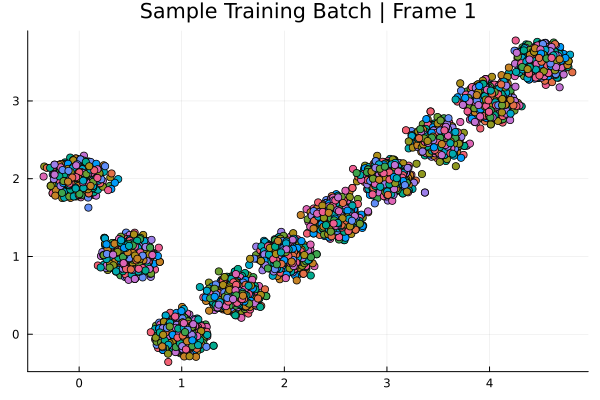

In [4]:
scatter(train_data[1, :, :], train_data[2, :, :], title="Sample Training Batch | Frame 1", legend=false)

In [5]:
# ======================================================================
# 1. ARCHITECTURE: The Arbitrary Edge Network
# ======================================================================
function build_network(N_atoms, D_dim, layer_dims=[32, 32])
    #activation always tanh after each layer, except the final output layer, to keep the messages bounded and stable during training
    input_dim = N_atoms * D_dim + 1 # Flattened positions of all atoms + time
    output_dim = N_atoms * D_dim # Output is the velocity for each atom, same shape as input positions
    layers = []
    prev_dim = input_dim
    for layer_dim in layer_dims
        push!(layers, Dense(prev_dim => layer_dim, tanh))
        prev_dim = layer_dim
    end
    push!(layers, Dense(prev_dim => output_dim, identity)) # Final output layer
    return Chain(layers...)
end

# ======================================================================
# 2. VECTOR FIELD: Tensorized CNF Dynamics with Exact Trace
# ======================================================================
function forward_mlp_generic_jvp(input, ps, jvp_probe)
    # Propagate value + JVP for all columns at once to avoid scalar indexing on GPU.
    val = input
    deriv = jvp_probe

    layer_keys = keys(ps)
    last_key = last(layer_keys)

    for key in layer_keys
        layer_ps = ps[key]
        W = layer_ps.weight
        b = layer_ps.bias

        pre_act = W * val .+ b
        pre_deriv = W * deriv

        if key == last_key
            val = pre_act
            deriv = pre_deriv
        else
            val = tanh.(pre_act)
            deriv = (one(eltype(input)) .- val.^2) .* pre_deriv
        end
    end

    return val, deriv
end


function basic_dynamics_with_logp(u, p, t; ϵ_in, ϵ_out)
    x = u.x       # Shape: (D, N, B)
    D, N, B = size(x)

    # reshape x into D*N rows and B columns for the MLP
    x_flat = reshape(x, D * N, B)
    # Append time to the input
    t_flat = x_flat[1:1, :] .* zero(eltype(x)) .+ eltype(x)(t)
    net_input = vcat(x_flat, t_flat) # Shape: (D*N + 1, B)
    
    dx_flat, hutch_jvp_flat = forward_mlp_generic_jvp(net_input, p, ϵ_in) # Shape: (D*N, B) for both vel_flat and hutch_jvp_flat
    dx = reshape(dx_flat, D, N, B) # Reshape back to (D, N, B)
    hutch_trace = sum(ϵ_out .* hutch_jvp_flat, dims=1) # Keep this as a plain 1 x B CuArray, not an Adjoint wrapper
    dlogp = -hutch_trace # dlogp/dt = -Trace(Jacobian)
    return ComponentArray(x = dx, logp = dlogp)
end


function basic_dynamics_no_logp(u, p, t; net)
    x = u.x       # Shape: (D, N, B)
    D, N, B = size(x)

    # reshape x into D*N rows and B columns for the MLP
    x_flat = reshape(x, D * N, B)
    # Append time to the input
    t_flat = ones(eltype(x), 1, B) .* eltype(x)(t)
    net_input = vcat(x_flat, t_flat) # Shape: (D*N + 1, B)
    
    dx_flat = net(net_input, p) # Shape: (D*N, B) for both vel_flat and hutch_jvp_flat
    dx = reshape(dx_flat, D, N, B) # Reshape back to (D, N, B)
    return ComponentArray(x = dx, logp = dlogp)
end

function exact_dynamics_with_logp(u, p, t; basis_vectors)
    x = u.x       # Shape: (D, N, B)
    D, N, B = size(x)
    K = D * N     # Total spatial dimensions (20 in your case)

    # Flatten x and append time
    x_flat = reshape(x, K, B)
    t_flat = x_flat[1:1, :] .* zero(eltype(x)) .+ eltype(x)(t)
    net_input = vcat(x_flat, t_flat) # Shape: (K + 1, B)
    
    # Initialize accumulator for the trace
    trace_accum = x_flat[1:1, :] .* zero(eltype(x))
    
    # Pre-declare dx_flat so it's accessible outside the loop
    local dx_flat
    
    # Loop over every spatial dimension to extract the Jacobian diagonal
    for i in 1:K
        # Extract the i-th basis vector and expand it across the batch
        # basis_vectors is a matrix of size (K+1, K)
        probe = repeat(basis_vectors[:, i:i], 1, B) 
        
        # Run your manual JVP
        val, jvp = forward_mlp_generic_jvp(net_input, p, probe)
        
        # We only need to save the velocity field from the first pass 
        # (the value output is identical regardless of the probe)
        if i == 1
            dx_flat = val 
        end
        
        # The i-th diagonal element of the Jacobian for each batch item 
        # is the i-th row of the returned JVP matrix. Accumulate it.
        trace_accum = trace_accum .+ jvp[i:i, :] 
    end

    dx = reshape(dx_flat, D, N, B)
    dlogp = -trace_accum # dlogp/dt = -Trace(Jacobian)
    
    return ComponentArray(x = dx, logp = dlogp)
end

exact_dynamics_with_logp (generic function with 1 method)

In [6]:
# ======================================================================
# 3. SETUP & INITIALIZATION
# ======================================================================
# Configuration
USE_GPU = true # Set to true and ensure `using CUDA` is added above if using NVIDIA GPUs
N_atoms = 10
B_size = 64
D_dim = 2
F_dim = 5
tspan = (0.0f0, 1.0f0)

# Setup device mapping (automatically handles GPU if requested and available)
dev = USE_GPU ? gpu_device() : cpu_device()

# Initialize Model
rng = Xoshiro(0)
cnf_net = build_network(N_atoms, D_dim, [64, 64, 64])
p_net, st_net = Lux.setup(rng, cnf_net)

# Move everything to the selected device
p = ComponentArray(p_net) |> dev
st = st_net |> dev

#create skeleton ODEProblem to be used for the remake in the loss function
# u0_dummy = ComponentArray(x = zeros(Float32, D_dim, N_atoms, B_size), logp = zeros(Float32, 1, B_size)) |> dev
# ϵ_dummy = randn(Float32, D_dim * N_atoms) |> dev # Random vector for Hutchinson's estimator
# ode_func = (u, p, t) -> basic_dynamics(u, p, t; net=cnf_net, ϵ=ϵ_dummy) # Define the locked-in ODE closure
# prob = ODEProblem(ode_func, u0_dummy, tspan, p)

(layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple(), layer_4 = NamedTuple())

In [7]:
# ======================================================================
# 4. LOSS FUNCTION & OPTIMIZATION
# ======================================================================
# Clean Gaussian Prior
function log_prior(x)
    # x shape: (D, N, B). We sum over D and N, leaving B.
    # log p(x) = -0.5 * ||x||^2 - (D*N/2)*log(2π)
    D, N, B = size(x)
    const_term = 0.5f0 * Float32(D * N) * log(2.0f0 * Float32(pi))
    s = sum(abs2, x, dims=(1,2)) # (1,1,B)
    lp = -0.5f0 .* reshape(s, 1, size(x,3)) .- const_term
    return lp
end

function nll_loss(params, x_batch, tspan=(0.0f0, 1.0f0))
    # 1. Initialize u0: State x at data, logp at 0, random ϵ for Hutchinson's estimator
    # Note: logp is (1, B) to match our dynamics output
    u0 = ComponentArray(x = x_batch, logp = zeros(Float32, 1, size(x_batch, 3))) |> dev

    #create random vector ϵ sampled from Rademacher distribution (±1 with equal probability) for Hutchinson's estimator
    B_curr = size(x_batch, 3)
    ϵ = rand(Float32, D_dim * N_atoms, B_curr) .> 0.5f0 # unique random vector for each sample in the batch
    ϵ = ϵ .* 2f0 .- 1f0 # Convert boolean to ±1
    ϵ_in = vcat(ϵ, zeros(Float32, 1, B_curr)) # ϵ_in needs a zero row for the time dimension across the whole batch
    ϵ_in = ϵ_in |> dev # Move probe vector to device
    ϵ_out = ϵ |> dev # Move to device

    ode_func = (u, p, t) -> basic_dynamics_with_logp(u, p, t; ϵ_in=ϵ_in, ϵ_out=ϵ_out) # Define the locked-in ODE closure

    # # Create standard basis vectors for the K spatial dimensions.
    # # We make it (K+1) x K because the network input includes time.
    # # The bottom row (time derivative) naturally stays 0.
    # D_dim, N_atoms, B_curr = size(x_batch)
    # K = D_dim * N_atoms
    # basis_vectors = Matrix{Float32}(I, K+1, K+1)[:, 1:K] |> dev
    
    # # Pass the basis vectors into the dynamics closure
    # ode_func = (u, p, t) -> exact_dynamics_with_logp(u, p, t; basis_vectors=basis_vectors)
    
    # 2. Solve forward: data (t=0) -> noise (t=1)
    prob = ODEProblem(ode_func, u0, tspan, params)
    #_prob = remake(prob, ode_func=ode_func, u0=u0, p=params) # Create a new problem instance with the current parameters and batch
    sol = solve(prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    
    # 3. Final outputs
    x_noise = sol.u[end].x
    delta_logp = sol.u[end].logp # ∫ -Trace dt
    
    # 4. Total NLL calculation
    # L = -log_prior(x_noise) + delta_logp
    # Note: delta_logp is (1, 1, B), log_prior is (1, B)
    log_pdata = log_prior(x_noise) .- delta_logp
    mean_nll = sum(-log_pdata) / size(x_batch, 3) 

    return mean_nll
end

# Usage in training loop:
# val, grads = Zygote.withgradient(p -> nll_loss(p, x_batch, prob), p_net)

nll_loss (generic function with 2 methods)

In [8]:
# ======================================================================
# 4. TEST FORWARD & BACKWARD PASS
# ======================================================================
println("Starting forward and backward pass...")
x_batch = train_data[:, :, 1:B_size] # (D, N, B)
#loss, grads = Zygote.withgradient(p_ -> nll_loss(p_, x_batch, prob), p)
loss, grads = Zygote.withgradient(nll_loss, p, x_batch)

println("Loss: ", loss)
println("Calculated gradients successfully!")

Starting forward and backward pass...
Loss: 75.65279
Calculated gradients successfully!


In [9]:
# ======================================================================
# 5. OPTIMIZER
# ======================================================================
learning_rate = 5f-3
opt = Optimisers.Adam(learning_rate)
opt_state = Optimisers.setup(opt, p)

Leaf(Adam(eta=0.005, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999)))

In [10]:
# ======================================================================
# 6. TRAIN LOOP
# ======================================================================
function train_adam(params, opt_state, train_data;
                    epochs=25,
                    batch_size=B_size,
                    rng=Xoshiro(42))
    n_samples = size(train_data, 3)
    n_batches = cld(n_samples, batch_size)
    loss_history = Float32[]

    for epoch in 1:epochs
        shuffled_idx = randperm(rng, n_samples)
        epoch_loss = 0f0

        for (batch_num, batch_start) in enumerate(1:batch_size:n_samples)
            batch_stop = min(batch_start + batch_size - 1, n_samples)
            batch_idx = shuffled_idx[batch_start:batch_stop]
            x_batch = train_data[:, :, batch_idx]
            local_batch_size = length(batch_idx)

            loss, grads = Zygote.withgradient(p_ -> nll_loss(p_, x_batch), params)
            grad_params = grads[1]
            grad_params === nothing && error("Zygote returned no gradient for the parameters.")

            opt_state, params = Optimisers.update(opt_state, params, grad_params)

            loss_f32 = Float32(loss)
            isfinite(loss_f32) || error("Non-finite loss at epoch=$epoch batch=$batch_num: $loss_f32")
            epoch_loss += loss_f32 * local_batch_size
            push!(loss_history, loss_f32)
        end

        @info "training" epoch batches=n_batches loss=(epoch_loss / n_samples)
    end

    return params, opt_state, loss_history
end


train_adam (generic function with 1 method)

In [11]:
n_epochs = 10

p, opt_state, loss_history = train_adam(p, opt_state, train_data;
                                        epochs=n_epochs,
                                        batch_size=B_size)

┌ Info: training
│   epoch = 1
│   batches = 16
│   loss = 28.076347
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:34
┌ Info: training
│   epoch = 2
│   batches = 16
│   loss = 12.139386
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:34
┌ Info: training
│   epoch = 3
│   batches = 16
│   loss = 8.335844
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:34
┌ Info: training
│   epoch = 4
│   batches = 16
│   loss = 4.2971206
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:34
┌ Info: training
│   epoch = 5
│   batches = 16
│   loss = 1.5593016
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X1

((layer_1 = (weight = Float32[-0.5205669 0.3607633 … -0.74671984 0.1395097; 0.047916282 -0.17782061 … 0.5543135 0.043620754; … ; -0.4694725 0.19887637 … -0.3387483 0.015180997; 0.26724395 0.015344962 … -0.33093053 0.63609684], bias = Float32[0.0061969985, -0.14439455, 0.07929261, 0.012261901, -0.19566031, -0.3193019, -0.04812288, 0.117134094, 0.12035502, 0.06833318  …  0.20281902, -0.57059336, 0.24913265, -0.5150204, -0.10347539, 0.11363778, 0.111229196, 0.14756852, -0.09177674, 0.017044352]), layer_2 = (weight = Float32[0.09620369 0.26129583 … -0.31123087 0.2727722; 0.08080532 0.38295433 … 0.17500396 -0.2454329; … ; -0.016606642 0.026365861 … 0.20391726 0.021144936; -0.1701082 0.2252453 … -0.018390369 -0.36650085], bias = Float32[-0.27976295, -0.07987693, 0.38053536, -0.2918091, 0.093469776, 0.010649794, -0.076819696, 0.02942164, 0.046915427, 0.023445858  …  0.0062541533, -0.07751327, 0.048109293, 0.05676402, 0.060418822, 0.0022146404, 0.046183124, -0.03202806, -0.09716807, 0.01929263

In [12]:
# ======================================================================
# 7. GENERATE SAMPLES FROM THE TRAINED MODEL
# ======================================================================
function generate_samples(params, n_samples=100)
    # 1. Initialize u0 with noise and zero logp
    u0 = ComponentArray(x = randn(Float32, D_dim, N_atoms, n_samples) |> dev, logp = zeros(Float32, 1, n_samples) |> dev)
    ϵ = rand(Float32, D_dim * N_atoms) .> 0.5f0 # Rademacher distribution: true for +1, false for -1
    ϵ = ϵ .* 2f0 .- 1f0 # Convert boolean to ±1
    ϵ_in = vcat(ϵ, zeros(Float32, 1)) # Append zero for time dimension to the probe vector
    ϵ_in = ϵ_in |> dev # Move probe vector to device
    ϵ_out = ϵ |> dev # Move to device

    ode_func = (u, p, t) -> basic_dynamics_with_logp(u, p, t; ϵ_in=ϵ_in, ϵ_out=ϵ_out) # Define the locked-in ODE closure
    prob = ODEProblem(ode_func, u0, (1.0f0, 0.0f0), params)
    sol = solve(prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-4, reltol=1e-4, dt=1f-4, verbose=false)
    x_samples = sol.u[end].x
    return x_samples
end

generate_samples (generic function with 2 methods)

In [13]:
samples = generate_samples(p, 1000) |> cpu_device();
#samples = randn(Float32, D_dim, N_atoms, 3)

2×10×1000 Array{Float32, 3}:
[:, :, 1] =
 0.781706  -0.160642  1.33221    …  2.91376  4.35986  4.29707  3.86293
 1.95608    1.2702    0.0383775     2.01955  2.60891  3.41312  3.18554

[:, :, 2] =
 -0.407543  1.53355  1.63422   …  2.80645  4.04131  4.41307  5.0037
  1.67343   1.03817  0.444977     1.34414  1.72099  2.70919  4.23105

[:, :, 3] =
 0.519062  -0.733431   0.8668    …  2.19098  2.78839  3.31018  2.1699
 1.61332    1.51123   -0.283664     1.15843  1.71147  2.50679  1.48699

;;; … 

[:, :, 998] =
 0.331291  0.784031   1.0324     …  1.79897  1.90534  2.03928  3.78852
 1.26199   0.838255  -0.0663384     1.95471  1.91834  1.74133  2.5713

[:, :, 999] =
 0.644313  0.321609   1.328     …  2.6491   3.04886  4.06216  3.38382
 2.04822   0.587396  -0.516299     1.95265  2.76728  2.83191  2.7022

[:, :, 1000] =
 -0.0330935  0.675892   0.668488  …  2.84391  3.05653  3.3242   3.84865
  1.52059    0.208719  -0.367358     1.97806  1.93239  2.97376  2.99352

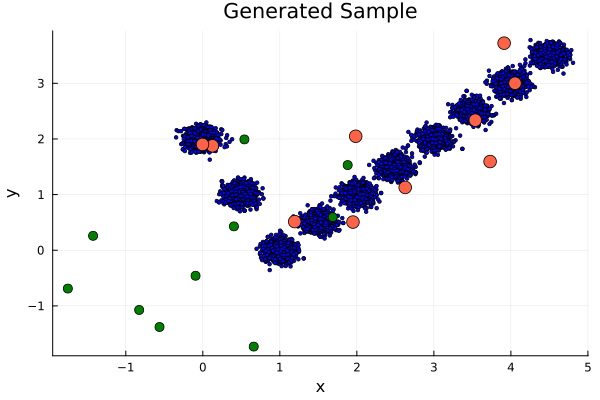

In [14]:
init_data = randn(Float32, D_dim, N_atoms, 1)
scatter(train_data[1, :, :], train_data[2, :, :], title="Generated Sample", xlabel="x", ylabel="y", markersize=2, markercolor=:blue, legend=false)
scatter!(samples[1, :, 100], samples[2, :, 100], markersize=7, markercolor=:tomato, legend=false)
scatter!(init_data[1, :, :], init_data[2, :, :], markersize=5, markercolor=:green, legend=false)



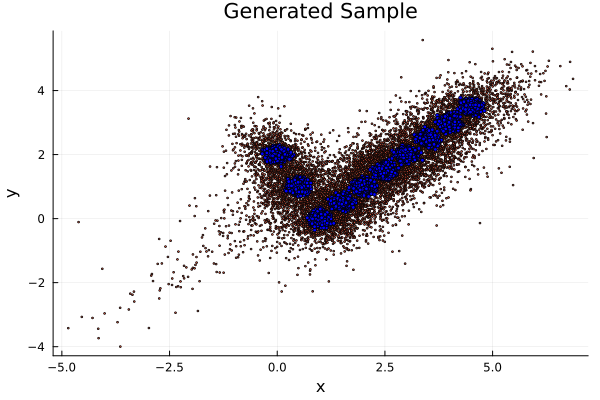

In [15]:
scatter(samples[1, :, :], samples[2, :, :], title="Generated Sample", xlabel="x", ylabel="y", markersize=1, markercolor=:tomato, legend=false)
scatter!(train_data[1, :, :], train_data[2, :, :], markersize=2, markercolor=:blue, legend=false)

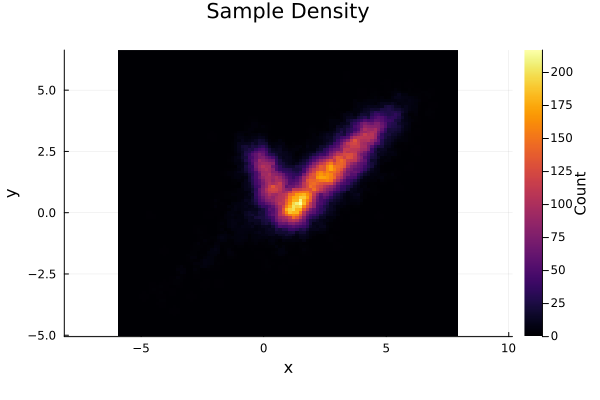

In [16]:
# make surface plot of the generated samples to visualize density
x_range = range(minimum(samples[1, :, :]) - 1f0, stop=maximum(samples[1, :, :]) + 1f0, length=100)
y_range = range(minimum(samples[2, :, :]) - 1f0, stop=maximum(samples[2, :, :]) + 1f0, length=100)
z_density = zeros(Float32, length(x_range), length(y_range))
for i in 1:length(x_range)
    for j in 1:length(y_range)
        # Count how many samples fall within a small radius of the grid point
        radius = 0.2f0
        count = sum((samples[1, :, :] .- x_range[i]).^2 .+ (samples[2, :, :] .- y_range[j]).^2 .< radius^2)
        z_density[i, j] = count    end
end
heatmap(x_range, y_range, z_density', title="Sample Density", xlabel="x", ylabel="y", colorbar_title="Count", aspect_ratio=:equal)


In [17]:
# function to calculate all pairwise distances for a D x N x B tensor of positions
# i want a pairwise distance matrix for each batch element, so output should be (N, N, B)
function pairwise_distances(positions)
    D, N, B = size(positions)
    # Expand dimensions to compute pairwise differences via broadcasting
    pos_i = reshape(positions, D, N, 1, B)
    pos_j = reshape(positions, D, 1, N, B)
    r_ij = pos_i .- pos_j
    d_ij = sqrt.(sum(abs2, r_ij, dims=1))
    return reshape(d_ij, N, N, B)
end

pairwise_distances (generic function with 1 method)

In [18]:
train_data_dists = pairwise_distances(train_data);
gen_data_dists = pairwise_distances(samples);

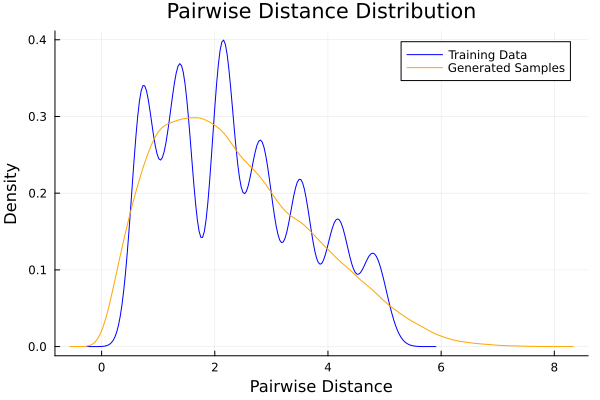

In [19]:
using StatsPlots
# Visualize the concordance of pairwise distance distributions between generated samples and training data
function visualize_distance_distributions(train_dists, gen_dists)
    # Flatten the upper triangle of the distance matrices to get 1D arrays of distances
    function upper_triangle_flat(dists)
        N = size(dists, 1)
        return [dists[i, j, b] for b in 1:size(dists, 3) for i in 1:N for j in (i+1):N]
    end
    train_flat = upper_triangle_flat(train_dists)
    gen_flat = upper_triangle_flat(gen_dists)
    # # Plot histograms
    # histogram(gen_flat, bins=50, alpha=0.5, label="Generated Samples", xlabel="Pairwise Distance", ylabel="Frequency", title="Pairwise Distance Distribution", color=:orange)
    # histogram!(train_flat, bins=50, alpha=0.5, label="Training Data", color=:blue)

    #plot density plots:
    density(train_flat, label="Training Data", xlabel="Pairwise Distance", ylabel="Density", title="Pairwise Distance Distribution", color=:blue)
    density!(gen_flat, label="Generated Samples", color=:orange)

    #legend()
end

visualize_distance_distributions(train_data_dists, gen_data_dists)